# Convergence Study

Established method: Rigid sliding block analysis
New method: Coupled sliding block analysis

The coupled sliding block method results should approach the same value(s) as the rigid sliding block analysis as the slope stiffness becomes very high.

In [ ]:
import itertools
import pandas as pd
import pyslammer as slam
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.interpolate import interp1d
from scipy.ndimage import uniform_filter1d


%matplotlib widget


In [109]:
# Parameters
kys = [0.25, 0.35, 0.45]  # g
target_pga = 0.5  # g
shear_wave_velocities = np.logspace(2, 3, 11, endpoint=True)
# shear_wave_velocities = np.linspace(10, 1000, 11, endpoint=True)
height = 10  # m
histories = slam.sample_ground_motions()


In [110]:
def run_analysis(ky, shear_wave_velocity, motion_name, gm):
    """Run a single analysis for given parameters."""
    rigid_inputs = {"ground_motion": gm, "ky": ky, "target_pga": target_pga}
    flexible_inputs = {
        "height": height,
        "vs_slope": shear_wave_velocity,
        "vs_base": shear_wave_velocity,
        "damp_ratio": 0.05,
        "ref_strain": 0.0005,
        "soil_model": "linear_elastic",
    }

    slope_period = 5 * height / shear_wave_velocity
    motion_period = gm.mean_period
    slope_freq = 1/slope_period
    motion_freq = 1/motion_period

    rigid_result = slam.RigidAnalysis(**rigid_inputs)
    coupled_result = slam.Coupled(**rigid_inputs, **flexible_inputs)

    return {
        "motion": motion_name,
        "ky": ky,
        "k_max": np.max(rigid_result.a_in),
        "shear_wave_vel": shear_wave_velocity,
        "tuning_ratio":  motion_freq / slope_freq,
        "d_max_rigid": rigid_result.max_sliding_disp,
        "d_max_coupled": coupled_result.max_sliding_disp,
    }


In [111]:
# Generate all parameter combinations
results = []
for ky, shear_wave_velocity, (motion_name, gm) in itertools.product(
    kys, shear_wave_velocities, histories.items()
):
    result = run_analysis(ky, shear_wave_velocity, motion_name, gm)
    results.append(result)
    # print(f"Completed: ky={ky}, vs={shear_wave_velocity}, motion={motion_name}")

# Convert to DataFrame
df_all = pd.DataFrame(results)
df = df_all[df_all["d_max_rigid"] > 0.0]


<>:56: SyntaxWarning: invalid escape sequence '\o'
<>:56: SyntaxWarning: invalid escape sequence '\o'
/var/folders/q0/kxmqm5c95n7cxc6mmqklw1k40000gq/T/ipykernel_88406/2871519406.py:56: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel("$\omega_o / \omega$")
/var/folders/q0/kxmqm5c95n7cxc6mmqklw1k40000gq/T/ipykernel_88406/2871519406.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10")  # Tableau 10 colors


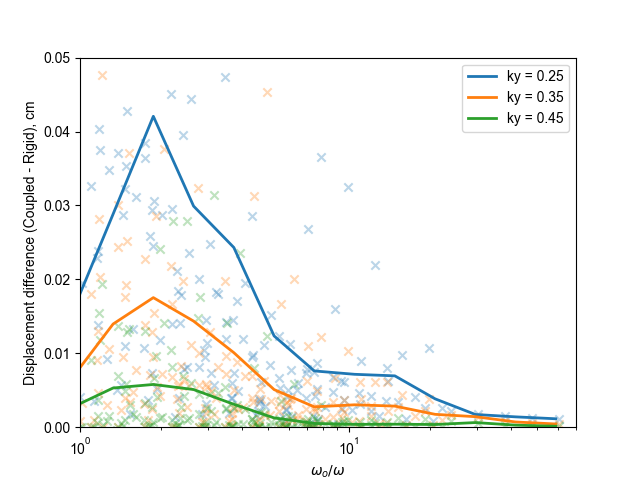

In [131]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["savefig.dpi"] = 600

fig, ax = plt.subplots()

cmap = cm.get_cmap("tab10")  # Tableau 10 colors
colors = [cmap(i) for i in range(len(kys))]
ky_color_map = dict(zip(kys, colors))

for ky, grp in df.groupby(["ky"]):
    ax.scatter(
        1 / grp["tuning_ratio"],
        grp["d_max_coupled"] - grp["d_max_rigid"],
        color=ky_color_map[ky[0]],
        marker="x",
        alpha=0.3,
    )

    # Binned average line
    x_vals = 1 / grp["tuning_ratio"]
    y_vals = grp["d_max_coupled"] - grp["d_max_rigid"]

    # Create logarithmic bins
    log_bins = np.logspace(np.log10(1e-1), np.log10(7e1), 20)
    bin_centers = []
    bin_means = []

    for i in range(len(log_bins) - 1):
        mask = (x_vals >= log_bins[i]) & (x_vals < log_bins[i + 1])
        if mask.sum() > 0:  # Only include bins with data
            bin_centers.append(np.sqrt(log_bins[i] * log_bins[i + 1]))  # Geometric mean
            bin_means.append(y_vals[mask].mean())

    if len(bin_centers) > 1:
        ax.plot(
            bin_centers,
            bin_means,
            color=ky_color_map[ky[0]],
            linewidth=2,
            label=f"ky = {ky[0]}",
        )
    # # Smooth line using interpolation
    # grp_sorted = grp.sort_values("tuning_ratio")
    # x_vals = 1 / grp_sorted["tuning_ratio"]
    # y_vals = grp_sorted["d_max_rigid"] - grp_sorted["d_max_coupled"]

    # # Apply smoothing filter
    # y_smooth = uniform_filter1d(y_vals, size=20)

    # ax.plot(x_vals, y_smooth, color=ky_color_map[ky[0]], linewidth=2, alpha=0.8)

ax.set_xlim(10e-1, 7e1)
ax.set_xscale("log")
ax.set_ylim(0, 0.05)
ax.set_xlabel("$\omega_o / \omega$")
ax.set_ylabel("Displacement difference (Coupled - Rigid), cm")
ax.legend()

# ax.grid(which="both")

# plt.tight_layout()
plt.show()


In [132]:
plt.savefig("convergence.pdf", dpi=600, bbox_inches="tight")


In [74]:
# plt.close("all")

Plan:
Use scatter plots with X markers and colors for different ky levels (one just above, one just below, and one well below target_pga).
For every ky level, take the average by bins of tuning ratios and plot the line using the same color as the X markers.